# Lab 1：银行股月度定投与分红再投资回测

## 0. 实验目标与口径说明

实验流程：**股票池 → 行情 → 分红 → 回测 → 指标 → 图表**。

对人工核验后的 A 股银行股票池，分别执行 10 年、5 年、3 年月度定投。
每月投入相同金额，按 100 股整数手买入，剩余资金留在账户；现金分红按每股口径入账，
并在除权除息日按当日不复权收盘价继续买回原股票。

### Key Assumptions

- 市场：沪深北 A 股；币种：人民币；
- 截止日：2026-07-24；
- 回测价格：不复权日线；前复权仅用于连续走势和技术研究；
- 不计算手续费和分红税；
- 分红数据没有独立到账日时，以除权除息日作为现金入账/再投资日，这是可见局限；
- 现金分红主源新浪，备源东方财富；只使用状态包含“实施”的记录；
- XIRR 只把月度投入视为外部现金流，账户内分红及再投资不是外部现金流；
- 上市晚于窗口起点或行情无法覆盖完整窗口时，比较指标记为 `N/A`；
- 历史回测不构成收益承诺。


## 1. 环境、参数和数据目录


In [1]:
import json
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()

# 从当前目录及其父级查找 labs/ 目录（其下需有 pyproject.toml）。
# 支持三种启动位置：仓库根目录、labs/、labs/<子目录>/（如 labs/01_银行股定投回测/）。
LABS_DIR = None
for _candidate in [WORKING_DIR, *WORKING_DIR.parents]:
    if _candidate.name == "labs" and (_candidate / "pyproject.toml").is_file():
        LABS_DIR = _candidate
        break
    if (_candidate / "labs" / "pyproject.toml").is_file():
        LABS_DIR = _candidate / "labs"
        break

if LABS_DIR is None:
    raise FileNotFoundError(
        "未找到 labs/pyproject.toml。请从仓库根目录、labs/ 或 labs/ 子目录启动 Jupyter。"
        f" 当前目录：{WORKING_DIR}"
    )

if str(LABS_DIR) not in sys.path:
    sys.path.insert(0, str(LABS_DIR))
sys.path.insert(0, str(LABS_DIR / "01_银行股定投回测"))

from bank_dca import (
    MANUAL_BANK_SYMBOLS,
    automatic_bank_candidates,
    compare_price_sources,
    fetch_dividends,
    fetch_exchange_stock_lists,
    fetch_f10_classification,
    fetch_price_bundle,
    finalize_bank_universe,
    simulate_bank_dca,
    validate_dividends,
    validate_price_frame,
)

AS_OF_DATE = "2026-07-24"
MONTHLY_AMOUNT = 3000
BUY_DAY = 1
LOT_SIZE = 100
DIVIDEND_REINVEST = True
HORIZONS = (10, 5, 3)

PRICE_REL_DIFF_TOLERANCE = 0.002
REQUIRE_DUAL_SOURCE_QC = True
REFRESH_UNIVERSE = False
REFRESH_MARKET_DATA = False
REFRESH_DIVIDENDS = False
SYMBOL_LIMIT = None  # 调试时可设为整数；正式实验保持 None

DATA_DIR = LABS_DIR / "01_银行股定投回测" / "data"
PRICE_DIR = DATA_DIR / "prices"
SOURCE_DIR = DATA_DIR / "source_snapshots"
DIVIDEND_DIR = DATA_DIR / "dividends"
RESULT_DIR = DATA_DIR / "results"
CHART_DIR = DATA_DIR / "charts"
for path in (DATA_DIR, PRICE_DIR, SOURCE_DIR, DIVIDEND_DIR, RESULT_DIR, CHART_DIR):
    path.mkdir(parents=True, exist_ok=True)

UNIVERSE_PATH = DATA_DIR / "bank_universe.csv"

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False

print({
    "AS_OF_DATE": AS_OF_DATE,
    "MONTHLY_AMOUNT": MONTHLY_AMOUNT,
    "BUY_DAY": BUY_DAY,
    "LOT_SIZE": LOT_SIZE,
    "DIVIDEND_REINVEST": DIVIDEND_REINVEST,
    "PRICE_REL_DIFF_TOLERANCE": PRICE_REL_DIFF_TOLERANCE,
})


{'AS_OF_DATE': '2026-07-24', 'MONTHLY_AMOUNT': 3000, 'BUY_DAY': 1, 'LOT_SIZE': 100, 'DIVIDEND_REINVEST': True, 'PRICE_REL_DIFF_TOLERANCE': 0.002}


## 2. 数据源路由配置


In [2]:
source_routes = pd.DataFrame([
    ("银行股票池", "交易所股票清单", "上交所+深交所+北交所", "PRIMARY"),
    ("行业验证", "mootdx F10", "通达信 TCP", "PRIMARY"),
    ("不复权行情", "stock_zh_a_hist_tx", "腾讯财经", "PRIMARY"),
    ("不复权行情", "stock_zh_a_daily", "新浪财经", "BACKUP+QC"),
    ("前复权行情", "stock_zh_a_hist_tx", "腾讯财经", "PRIMARY"),
    ("前复权行情", "stock_zh_a_daily", "新浪财经", "BACKUP"),
    ("历史行情", "mootdx.bars", "通达信 TCP", "DEFERRED"),
    ("历史行情", "stock_zh_a_hist", "东方财富", "DISABLED"),
    ("分红", "stock_history_dividend_detail", "新浪财经", "PRIMARY"),
    ("分红", "stock_fhps_detail_em", "东方财富", "BACKUP"),
], columns=["数据", "接口", "真实上游", "路由决策"])
display(source_routes)


,数据,接口,真实上游,路由决策
0,银行股票池,交易所股票清单,上交所+深交所+北交所,PRIMARY
1,行业验证,mootdx F10,通达信 TCP,PRIMARY
2,不复权行情,stock_zh_a_hist_tx,腾讯财经,PRIMARY
3,不复权行情,stock_zh_a_daily,新浪财经,BACKUP+QC
4,前复权行情,stock_zh_a_hist_tx,腾讯财经,PRIMARY
5,前复权行情,stock_zh_a_daily,新浪财经,BACKUP
6,历史行情,mootdx.bars,通达信 TCP,DEFERRED
7,历史行情,stock_zh_a_hist,东方财富,DISABLED
8,分红,stock_history_dividend_detail,新浪财经,PRIMARY
9,分红,stock_fhps_detail_em,东方财富,BACKUP


## 3. 构建银行股票池

```text
上交所股票清单 + 深交所股票清单 + 北交所股票清单
        ↓
名称/交易所行业做宽松初筛
        ↓
mootdx F10 主营业务文本确认
        ↓
2026-07-24 人工核验清单审计
        ↓
data/bank_universe.csv
```

通达信当前服务器的 F10 实测通常只返回“最新提示”，没有稳定的结构化行业字段。
因此本实验读取其中的主营业务文本做验证，并保留文本哈希；北交所 F10 当前不支持时
明确记录，不补造行业。


In [3]:
if UNIVERSE_PATH.is_file() and not REFRESH_UNIVERSE:
    bank_universe = pd.read_csv(
        UNIVERSE_PATH,
        dtype={"symbol": "string"},
        parse_dates=["list_date", "manual_review_as_of"],
    )
    exchange_universe = pd.read_parquet(DATA_DIR / "exchange_stock_list.parquet")
    f10_review = pd.read_csv(
        DATA_DIR / "bank_universe_f10_review.csv",
        dtype={"symbol": "string"},
    )
else:
    exchange_universe = fetch_exchange_stock_lists()
    exchange_universe.to_parquet(
        DATA_DIR / "exchange_stock_list.parquet", index=False
    )
    candidates = automatic_bank_candidates(exchange_universe)
    f10_review = fetch_f10_classification(candidates)
    f10_review.to_csv(
        DATA_DIR / "bank_universe_f10_review.csv",
        index=False,
        encoding="utf-8-sig",
    )
    bank_universe = finalize_bank_universe(
        exchange_universe,
        f10_review,
        as_of_date=AS_OF_DATE,
    )
    bank_universe.to_csv(
        UNIVERSE_PATH, index=False, encoding="utf-8-sig"
    )

assert set(bank_universe["symbol"].astype(str).str.zfill(6)) == set(MANUAL_BANK_SYMBOLS)
assert bank_universe["manual_verified"].all()
print(f"全市场 A 股: {len(exchange_universe):,}；人工核验银行: {len(bank_universe)}")
display(
    bank_universe[
        [
            "symbol", "name", "exchange", "list_date", "exchange_industry",
            "f10_status", "f10_matches", "f10_review_required",
        ]
    ]
)
print(f"股票池快照: {UNIVERSE_PATH.relative_to(LABS_DIR)}")


2026-07-25 14:45:32,207 - mootdx - WARNING - 未找到配置文件 C:\Users\theTruth\.mootdx\config.json, 正在生成配置文件.
2026-07-25 14:45:32,209 - mootdx - INFO - [-] 选择最快的服务器...
2026-07-25 14:45:32,212 - mootdx - ERROR - 请手动运行`python -m mootdx bestip`
C:\Users\theTruth\Documents\projects\vibe-working\trading-topic\labs\.venv\Lib\site-packages\mootdx\server.py:187: RuntimeWarning: coroutine 'wait' was never awaited
  break


全市场 A 股: 5,531；人工核验银行: 42


,symbol,name,exchange,list_date,exchange_industry,f10_status,f10_matches,f10_review_required
0,000001,平安银行,SZSE,1991-04-03,J 金融业,AVAILABLE,银行|吸收公众存款|发放贷款|存贷款|商业银行,False
1,001227,兰州银行,SZSE,2022-01-17,J 金融业,AVAILABLE,银行|吸收公众存款|存贷款|商业银行,False
2,002142,宁波银行,SZSE,2007-07-19,J 金融业,AVAILABLE,银行|吸收公众存款,False
3,002807,江阴银行,SZSE,2016-09-02,J 金融业,AVAILABLE,银行|吸收公众存款|商业银行,False
4,002839,张家港行,SZSE,2017-01-24,J 金融业,AVAILABLE,银行|吸收公众存款|商业银行,False
5,002936,郑州银行,SZSE,2018-09-19,J 金融业,AVAILABLE,银行,True
6,002948,青岛银行,SZSE,2019-01-16,J 金融业,AVAILABLE,银行,True
7,002958,青农商行,SZSE,2019-03-26,J 金融业,AVAILABLE,银行|零售金融|公司金融|商业银行,False
8,002966,苏州银行,SZSE,2019-08-02,J 金融业,AVAILABLE,银行|吸收公众存款|公司金融|商业银行,False
9,600000,浦发银行,SSE,1999-11-10,,AVAILABLE,银行|商业银行,False


股票池快照: 01_银行股定投回测\data\bank_universe.csv


## 4. 下载并缓存不复权行情

主源为腾讯，新浪同时承担备源与质量校验源。每只股票的正式行情保存为
`<symbol>_daily_raw.parquet`；新浪独立快照保存在 `source_snapshots/`。
东方财富历史行情不会被调用。


In [4]:
analysis_universe = (
    bank_universe.head(SYMBOL_LIMIT).copy()
    if SYMBOL_LIMIT else bank_universe.copy()
)
history_start = (
    pd.Timestamp(AS_OF_DATE) - pd.DateOffset(years=max(HORIZONS))
    - pd.Timedelta(days=30)
).strftime("%Y%m%d")
history_end = pd.Timestamp(AS_OF_DATE).strftime("%Y%m%d")

price_route_rows = []
for position, row in enumerate(analysis_universe.itertuples(index=False), start=1):
    symbol = str(row.symbol).zfill(6)
    raw_path = PRICE_DIR / f"{symbol}_daily_raw.parquet"
    qfq_path = PRICE_DIR / f"{symbol}_daily_qfq.parquet"
    secondary_path = SOURCE_DIR / f"{symbol}_daily_sina_raw.parquet"
    try:
        if (
            raw_path.is_file() and qfq_path.is_file()
            and secondary_path.is_file() and not REFRESH_MARKET_DATA
        ):
            raw = pd.read_parquet(raw_path)
            qfq = pd.read_parquet(qfq_path)
            secondary = pd.read_parquet(secondary_path)
            comparison = compare_price_sources(
                raw if raw["source"].iloc[0].endswith("腾讯财经") else pd.DataFrame(),
                secondary,
                relative_tolerance=PRICE_REL_DIFF_TOLERANCE,
            ) if raw["source"].iloc[0].endswith("腾讯财经") else {
                "status": "UNAVAILABLE", "common_dates": 0,
                "max_relative_diff": np.nan, "mean_relative_diff": np.nan,
                "breach_count": 0, "threshold": PRICE_REL_DIFF_TOLERANCE,
            }
            route = {
                "raw_source": (
                    "stock_zh_a_hist_tx"
                    if raw["source"].iloc[0].endswith("腾讯财经")
                    else "stock_zh_a_daily"
                ),
                "qfq_source": (
                    "stock_zh_a_hist_tx"
                    if qfq["source"].iloc[0].endswith("腾讯财经")
                    else "stock_zh_a_daily"
                ),
                "cache_hit": True,
                "mootdx_bars": "DEFERRED",
                "eastmoney_stock_zh_a_hist": "DISABLED",
            }
        else:
            bundle = fetch_price_bundle(
                symbol,
                history_start,
                history_end,
                relative_tolerance=PRICE_REL_DIFF_TOLERANCE,
            )
            raw, qfq, secondary = bundle.raw, bundle.qfq, bundle.secondary_raw
            comparison, route = bundle.comparison, bundle.route
            route["cache_hit"] = False
            raw.to_parquet(raw_path, index=False)
            qfq.to_parquet(qfq_path, index=False)
            secondary.to_parquet(secondary_path, index=False)

        raw_quality = validate_price_frame(raw)
        qfq_quality = validate_price_frame(qfq)
        price_route_rows.append({
            "symbol": symbol,
            "name": row.name,
            "download_status": "AVAILABLE",
            **route,
            **{f"source_compare_{key}": value for key, value in comparison.items()},
            **{f"raw_{key}": value for key, value in raw_quality.items()},
            **{f"qfq_{key}": value for key, value in qfq_quality.items()},
        })
    except Exception as error:
        price_route_rows.append({
            "symbol": symbol,
            "name": row.name,
            "download_status": "BROKEN",
            "error": f"{type(error).__name__}: {str(error)[:160]}",
        })
    print(f"[{position:02d}/{len(analysis_universe):02d}] {symbol} {row.name}")

price_routes = pd.DataFrame(price_route_rows)
price_routes.to_csv(
    DATA_DIR / "price_routes.csv", index=False, encoding="utf-8-sig"
)
display(
    price_routes[
        [
            "symbol", "name", "download_status", "raw_source", "qfq_source",
            "source_compare_status", "source_compare_max_relative_diff",
            "raw_status", "qfq_status",
        ]
    ]
)


[01/42] 000001 平安银行
[02/42] 001227 兰州银行
[03/42] 002142 宁波银行
[04/42] 002807 江阴银行
[05/42] 002839 张家港行
[06/42] 002936 郑州银行
[07/42] 002948 青岛银行
[08/42] 002958 青农商行
[09/42] 002966 苏州银行
[10/42] 600000 浦发银行
[11/42] 600015 华夏银行
[12/42] 600016 民生银行
[13/42] 600036 招商银行
[14/42] 600908 无锡银行
[15/42] 600919 江苏银行
[16/42] 600926 杭州银行
[17/42] 600928 西安银行
[18/42] 601009 南京银行
[19/42] 601077 渝农商行
[20/42] 601128 常熟银行
[21/42] 601166 兴业银行
[22/42] 601169 北京银行
[23/42] 601187 厦门银行
[24/42] 601229 上海银行
[25/42] 601288 农业银行
[26/42] 601328 交通银行
[27/42] 601398 工商银行
[28/42] 601528 瑞丰银行
[29/42] 601577 长沙银行
[30/42] 601658 邮储银行
[31/42] 601665 齐鲁银行
[32/42] 601818 光大银行
[33/42] 601825 沪农商行
[34/42] 601838 成都银行
[35/42] 601860 紫金银行
[36/42] 601916 浙商银行
[37/42] 601939 建设银行
[38/42] 601963 重庆银行
[39/42] 601988 中国银行
[40/42] 601997 贵阳银行
[41/42] 601998 中信银行
[42/42] 603323 苏农银行


,symbol,name,download_status,raw_source,qfq_source,source_compare_status,source_compare_max_relative_diff,raw_status,qfq_status
0,000001,平安银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
1,001227,兰州银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
2,002142,宁波银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
3,002807,江阴银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
4,002839,张家港行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
5,002936,郑州银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
6,002948,青岛银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
7,002958,青农商行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
8,002966,苏州银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS
9,600000,浦发银行,AVAILABLE,stock_zh_a_hist_tx,stock_zh_a_hist_tx,PASS,0.000000,PASS,PASS


## 5. 下载前复权行情

前一节为减少重复请求，已与不复权行情一并下载。这里只验证每只股票都存在两份正式行情：

- `<symbol>_daily_raw.parquet`：实际买入价格、持仓市值和交易回测；
- `<symbol>_daily_qfq.parquet`：连续走势和技术指标；

后复权价格不用于实际交易模拟，本实验暂不落盘。


In [5]:
price_files = pd.DataFrame([
    {
        "symbol": str(row.symbol).zfill(6),
        "raw_exists": (PRICE_DIR / f"{str(row.symbol).zfill(6)}_daily_raw.parquet").is_file(),
        "qfq_exists": (PRICE_DIR / f"{str(row.symbol).zfill(6)}_daily_qfq.parquet").is_file(),
    }
    for row in analysis_universe.itertuples(index=False)
])
display(price_files)


,symbol,raw_exists,qfq_exists
0,000001,True,True
1,001227,True,True
2,002142,True,True
3,002807,True,True
4,002839,True,True
5,002936,True,True
6,002948,True,True
7,002958,True,True
8,002966,True,True
9,600000,True,True


## 6. 下载和标准化分红数据


In [6]:
dividend_route_rows = []
for position, row in enumerate(analysis_universe.itertuples(index=False), start=1):
    symbol = str(row.symbol).zfill(6)
    dividend_path = DIVIDEND_DIR / f"{symbol}_dividend.parquet"
    try:
        if dividend_path.is_file() and not REFRESH_DIVIDENDS:
            dividends = pd.read_parquet(dividend_path)
            cached_source = (
                str(dividends["source"].iloc[0])
                if not dividends.empty else ""
            )
            route = {
                "selected_source": (
                    "stock_history_dividend_detail"
                    if cached_source == "新浪财经"
                    else "stock_fhps_detail_em"
                    if cached_source == "东方财富"
                    else "UNKNOWN_EMPTY_CACHE"
                ),
                "cache_hit": True,
                "sina_error": "",
                "eastmoney_error": "",
            }
        else:
            dividends, route = fetch_dividends(symbol)
            route["cache_hit"] = False
            dividends.to_parquet(dividend_path, index=False)
        dividend_route_rows.append({
            "symbol": symbol,
            "name": row.name,
            "download_status": "AVAILABLE",
            "rows": len(dividends),
            **route,
        })
    except Exception as error:
        dividend_route_rows.append({
            "symbol": symbol,
            "name": row.name,
            "download_status": "BROKEN",
            "rows": 0,
            "error": f"{type(error).__name__}: {str(error)[:160]}",
        })
    print(f"[{position:02d}/{len(analysis_universe):02d}] {symbol} {row.name}")

dividend_routes = pd.DataFrame(dividend_route_rows)
dividend_routes.to_csv(
    DATA_DIR / "dividend_routes.csv", index=False, encoding="utf-8-sig"
)
display(dividend_routes)


[01/42] 000001 平安银行
[02/42] 001227 兰州银行
[03/42] 002142 宁波银行
[04/42] 002807 江阴银行
[05/42] 002839 张家港行
[06/42] 002936 郑州银行
[07/42] 002948 青岛银行
[08/42] 002958 青农商行
[09/42] 002966 苏州银行
[10/42] 600000 浦发银行
[11/42] 600015 华夏银行
[12/42] 600016 民生银行
[13/42] 600036 招商银行
[14/42] 600908 无锡银行
[15/42] 600919 江苏银行
[16/42] 600926 杭州银行
[17/42] 600928 西安银行
[18/42] 601009 南京银行
[19/42] 601077 渝农商行
[20/42] 601128 常熟银行
[21/42] 601166 兴业银行
[22/42] 601169 北京银行
[23/42] 601187 厦门银行
[24/42] 601229 上海银行
[25/42] 601288 农业银行
[26/42] 601328 交通银行
[27/42] 601398 工商银行
[28/42] 601528 瑞丰银行
[29/42] 601577 长沙银行
[30/42] 601658 邮储银行
[31/42] 601665 齐鲁银行
[32/42] 601818 光大银行
[33/42] 601825 沪农商行
[34/42] 601838 成都银行
[35/42] 601860 紫金银行
[36/42] 601916 浙商银行
[37/42] 601939 建设银行
[38/42] 601963 重庆银行
[39/42] 601988 中国银行
[40/42] 601997 贵阳银行
[41/42] 601998 中信银行
[42/42] 603323 苏农银行


,symbol,name,download_status,rows,selected_source,sina_error,eastmoney_error,cache_hit
0,000001,平安银行,AVAILABLE,29,stock_history_dividend_detail,,,False
1,001227,兰州银行,AVAILABLE,7,stock_history_dividend_detail,,,False
2,002142,宁波银行,AVAILABLE,20,stock_history_dividend_detail,,,False
3,002807,江阴银行,AVAILABLE,11,stock_history_dividend_detail,,,False
4,002839,张家港行,AVAILABLE,11,stock_history_dividend_detail,,,False
5,002936,郑州银行,AVAILABLE,5,stock_history_dividend_detail,,,False
6,002948,青岛银行,AVAILABLE,8,stock_history_dividend_detail,,,False
7,002958,青农商行,AVAILABLE,7,stock_history_dividend_detail,,,False
8,002966,苏州银行,AVAILABLE,9,stock_history_dividend_detail,,,False
9,600000,浦发银行,AVAILABLE,26,stock_history_dividend_detail,,,False


## 7. 行情与分红质量检查

致命检查包括日期重复、非升序、空收盘价、最低价高于最高价、负成交量和非正 OHLC。
长时间无交易只标为待核查，因为停牌可能是真实事件。

腾讯和新浪不复权收盘价在共同交易日的相对差异阈值为 `0.2%`。只要存在超阈值日期，
该股票就停止回测，而不是带病继续计算。启用严格模式时，缺少第二来源也停止回测。


In [7]:
quality_rows = []
for row in analysis_universe.itertuples(index=False):
    symbol = str(row.symbol).zfill(6)
    raw_path = PRICE_DIR / f"{symbol}_daily_raw.parquet"
    qfq_path = PRICE_DIR / f"{symbol}_daily_qfq.parquet"
    secondary_path = SOURCE_DIR / f"{symbol}_daily_sina_raw.parquet"
    dividend_path = DIVIDEND_DIR / f"{symbol}_dividend.parquet"
    if not all(path.is_file() for path in (raw_path, qfq_path, secondary_path, dividend_path)):
        quality_rows.append({
            "symbol": symbol, "name": row.name, "eligible_for_backtest": False,
            "stop_reason": "缺少行情或分红缓存",
        })
        continue

    raw = pd.read_parquet(raw_path)
    qfq = pd.read_parquet(qfq_path)
    secondary = pd.read_parquet(secondary_path)
    dividends = pd.read_parquet(dividend_path)
    raw_check = validate_price_frame(raw)
    qfq_check = validate_price_frame(qfq)
    dividend_check = validate_dividends(dividends, raw)

    if raw["source"].iloc[0].endswith("腾讯财经"):
        source_check = compare_price_sources(
            raw, secondary, relative_tolerance=PRICE_REL_DIFF_TOLERANCE
        )
    else:
        source_check = {
            "status": "UNAVAILABLE", "common_dates": 0,
            "max_relative_diff": np.nan, "mean_relative_diff": np.nan,
            "breach_count": 0, "threshold": PRICE_REL_DIFF_TOLERANCE,
        }

    stop_reasons = []
    if raw_check["status"] != "PASS":
        stop_reasons.append(raw_check["fatal_issues"])
    if qfq_check["status"] != "PASS":
        stop_reasons.append(qfq_check["fatal_issues"])
    if dividend_check["status"] == "FAIL":
        stop_reasons.append(dividend_check["fatal_issues"])
    if source_check["status"] == "FAIL":
        stop_reasons.append(
            f"腾讯/新浪收盘价存在 {source_check['breach_count']} 个超阈值日期"
        )
    if REQUIRE_DUAL_SOURCE_QC and source_check["status"] != "PASS":
        stop_reasons.append(f"双源校验状态={source_check['status']}")

    quality_rows.append({
        "symbol": symbol,
        "name": row.name,
        "eligible_for_backtest": not stop_reasons,
        "stop_reason": "; ".join(filter(None, stop_reasons)),
        "raw_status": raw_check["status"],
        "raw_rows": raw_check["rows"],
        "raw_maximum_calendar_gap_days": raw_check["maximum_calendar_gap_days"],
        "raw_warnings": raw_check["warnings"],
        "qfq_status": qfq_check["status"],
        "source_compare_status": source_check["status"],
        "source_common_dates": source_check["common_dates"],
        "source_max_relative_diff": source_check["max_relative_diff"],
        "source_breach_count": source_check["breach_count"],
        "dividend_status": dividend_check["status"],
        "dividend_rows": dividend_check["rows"],
        "dividend_warnings": dividend_check["warnings"],
    })

quality_report = pd.DataFrame(quality_rows)
quality_report.to_csv(
    DATA_DIR / "quality_report.csv", index=False, encoding="utf-8-sig"
)
display(quality_report)
print(
    f"通过: {quality_report['eligible_for_backtest'].sum()} / "
    f"{len(quality_report)}"
)


,symbol,name,eligible_for_backtest,stop_reason,raw_status,raw_rows,raw_maximum_calendar_gap_days,raw_warnings,qfq_status,source_compare_status,source_common_dates,source_max_relative_diff,source_breach_count,dividend_status,dividend_rows,dividend_warnings
0,000001,平安银行,True,,PASS,2449,11,,PASS,PASS,2449,0.000000,0,PASS,29,17 条分红在当前行情范围外，回测时忽略
1,001227,兰州银行,True,,PASS,1094,11,,PASS,PASS,1094,0.000000,0,PASS,7,
2,002142,宁波银行,True,,PASS,2443,11,,PASS,PASS,2443,0.000000,0,PASS,20,8 条分红在当前行情范围外，回测时忽略
3,002807,江阴银行,True,,PASS,2391,13,,PASS,PASS,2391,0.000000,0,PASS,11,
4,002839,张家港行,True,,PASS,2294,20,,PASS,PASS,2294,0.000000,0,PASS,11,
5,002936,郑州银行,True,,PASS,1900,11,,PASS,PASS,1900,0.000000,0,PASS,5,
6,002948,青岛银行,True,,PASS,1817,11,,PASS,PASS,1817,0.000000,0,PASS,8,
7,002958,青农商行,True,,PASS,1779,11,,PASS,PASS,1779,0.000000,0,PASS,7,
8,002966,苏州银行,True,,PASS,1691,11,,PASS,PASS,1691,0.000000,0,PASS,9,
9,600000,浦发银行,True,,PASS,2449,11,,PASS,PASS,2449,0.000000,0,PASS,26,16 条分红在当前行情范围外，回测时忽略


通过: 40 / 42


## 8. 定义月度定投算法

每个窗口的第一笔交易是窗口起始日当天或之后的第一个交易日；以后每月在
`BUY_DAY` 当天或之后的第一个交易日投入。现金先进入账户，再按收盘价购买尽可能多的
100 股整数手，剩余现金保留。交易日志逐笔记录日期、价格、股数、金额、现金、持股和累计投入。


## 9. 定义分红再投资算法

以股权登记日收盘后的持股数计算应收现金分红；数据未提供实际到账日时，以除权除息日
作为现金入账日。入账后按当日不复权收盘价购买整数手，买不满一手的现金继续留存。
不计算分红税。


## 10. 定义 XIRR 和风险指标

- `xirr`：实际日期现金流年化收益率；
- `max_drawdown`：基于不复权价格加现金分红再投资构建的标的总收益净值最大回撤；
- `max_loss_vs_contribution`：定投账户
  `(账户资产-累计投入)/累计投入` 的历史最低值；
- `volatility`：标的总收益净值日收益率的 252 日年化波动率。

这两个回撤指标回答不同问题，不能互换。


In [8]:
metric_definitions = pd.DataFrame([
    ("total_return", "期末账户资产 / 累计投入 - 1"),
    ("xirr", "月度投入与期末资产的实际日期内部收益率"),
    ("max_drawdown", "标的含现金分红再投资总收益净值最大回撤"),
    ("max_loss_vs_contribution", "定投账户相对累计投入的历史最低浮亏"),
    ("volatility", "标的总收益日收益率 × sqrt(252)"),
], columns=["指标", "定义"])
display(metric_definitions)


,指标,定义
0,total_return,期末账户资产 / 累计投入 - 1
1,xirr,月度投入与期末资产的实际日期内部收益率
2,max_drawdown,标的含现金分红再投资总收益净值最大回撤
3,max_loss_vs_contribution,定投账户相对累计投入的历史最低浮亏
4,volatility,标的总收益日收益率 × sqrt(252)


## 11. 运行 10 年、5 年、3 年回测


In [9]:
summary_rows = []
transaction_frames = []
account_frames = []
total_return_frames = []
quality_by_symbol = quality_report.assign(
    symbol=quality_report["symbol"].astype(str).str.zfill(6)
).set_index("symbol")

def empty_result_row(row, horizon, *, status, reason):
    requested_start = (
        pd.Timestamp(AS_OF_DATE) - pd.DateOffset(years=horizon)
    )
    return {
        "symbol": str(row.symbol).zfill(6),
        "name": row.name,
        "horizon": f"{horizon}Y",
        "requested_start_date": requested_start,
        "start_date": pd.NaT,
        "end_date": pd.NaT,
        "listing_date": row.list_date,
        "full_horizon": False,
        "contribution_months": np.nan,
        "total_contribution": np.nan,
        "ending_shares": np.nan,
        "ending_cash": np.nan,
        "ending_market_value": np.nan,
        "ending_asset": np.nan,
        "total_dividend": np.nan,
        "total_return": np.nan,
        "xirr": np.nan,
        "average_buy_price": np.nan,
        "current_profit_rate": np.nan,
        "max_drawdown": np.nan,
        "max_loss_vs_contribution": np.nan,
        "volatility": np.nan,
        "dividend_reinvest": DIVIDEND_REINVEST,
        "backtest_status": status,
        "stop_reason": reason,
    }

for position, row in enumerate(analysis_universe.itertuples(index=False), start=1):
    symbol = str(row.symbol).zfill(6)
    quality = quality_by_symbol.loc[symbol]
    if not bool(quality["eligible_for_backtest"]):
        for horizon in HORIZONS:
            summary_rows.append(
                empty_result_row(
                    row,
                    horizon,
                    status="BLOCKED_DATA_QUALITY",
                    reason=str(quality["stop_reason"]),
                )
            )
        print(
            f"[{position:02d}/{len(analysis_universe):02d}] "
            f"{symbol} {row.name} BLOCKED_DATA_QUALITY"
        )
        continue

    raw = pd.read_parquet(PRICE_DIR / f"{symbol}_daily_raw.parquet")
    dividends = pd.read_parquet(DIVIDEND_DIR / f"{symbol}_dividend.parquet")
    for horizon in HORIZONS:
        try:
            output = simulate_bank_dca(
                symbol=symbol,
                name=row.name,
                prices=raw,
                dividends=dividends,
                listing_date=row.list_date,
                as_of_date=AS_OF_DATE,
                horizon_years=horizon,
                monthly_amount=MONTHLY_AMOUNT,
                buy_day=BUY_DAY,
                lot_size=LOT_SIZE,
                dividend_reinvest=DIVIDEND_REINVEST,
            )
            output.summary["backtest_status"] = (
                "COMPLETED"
                if output.summary["full_horizon"]
                else "INCOMPLETE_WINDOW"
            )
            output.summary["stop_reason"] = ""
            summary_rows.append(output.summary)
            transaction_frames.append(output.transactions)
            account_frames.append(output.account_history)
            total_return_frames.append(output.total_return_history)
        except Exception as error:
            summary_rows.append(
                empty_result_row(
                    row,
                    horizon,
                    status="ERROR",
                    reason=f"{type(error).__name__}: {str(error)[:160]}",
                )
            )
    print(f"[{position:02d}/{len(analysis_universe):02d}] {symbol} {row.name}")

results = pd.DataFrame(summary_rows)
transactions = pd.concat(transaction_frames, ignore_index=True) if transaction_frames else pd.DataFrame()
account_history = pd.concat(account_frames, ignore_index=True) if account_frames else pd.DataFrame()
total_return_history = pd.concat(total_return_frames, ignore_index=True) if total_return_frames else pd.DataFrame()

assert len(results) == len(analysis_universe) * len(HORIZONS)
assert not results.duplicated(["symbol", "horizon"]).any()
results.to_csv(RESULT_DIR / "backtest_results.csv", index=False, encoding="utf-8-sig")
transactions.to_parquet(RESULT_DIR / "transactions.parquet", index=False)
account_history.to_parquet(RESULT_DIR / "account_history.parquet", index=False)
total_return_history.to_parquet(RESULT_DIR / "total_return_history.parquet", index=False)
print(f"结果行数: {len(results)}")


[01/42] 000001 平安银行
[02/42] 001227 兰州银行
[03/42] 002142 宁波银行
[04/42] 002807 江阴银行
[05/42] 002839 张家港行
[06/42] 002936 郑州银行
[07/42] 002948 青岛银行
[08/42] 002958 青农商行
[09/42] 002966 苏州银行
[10/42] 600000 浦发银行
[11/42] 600015 华夏银行
[12/42] 600016 民生银行
[13/42] 600036 招商银行
[14/42] 600908 无锡银行
[15/42] 600919 江苏银行
[16/42] 600926 杭州银行
[17/42] 600928 西安银行
[18/42] 601009 南京银行
[19/42] 601077 渝农商行
[20/42] 601128 常熟银行
[21/42] 601166 兴业银行
[22/42] 601169 北京银行
[23/42] 601187 厦门银行
[24/42] 601229 上海银行 BLOCKED_DATA_QUALITY
[25/42] 601288 农业银行
[26/42] 601328 交通银行
[27/42] 601398 工商银行
[28/42] 601528 瑞丰银行
[29/42] 601577 长沙银行
[30/42] 601658 邮储银行
[31/42] 601665 齐鲁银行
[32/42] 601818 光大银行 BLOCKED_DATA_QUALITY
[33/42] 601825 沪农商行
[34/42] 601838 成都银行
[35/42] 601860 紫金银行
[36/42] 601916 浙商银行
[37/42] 601939 建设银行
[38/42] 601963 重庆银行
[39/42] 601988 中国银行
[40/42] 601997 贵阳银行
[41/42] 601998 中信银行
[42/42] 603323 苏农银行
结果行数: 126


## 12. 汇总结果表


In [10]:
required_result_columns = [
    "symbol", "name", "horizon", "start_date", "end_date",
    "contribution_months", "total_contribution", "ending_shares",
    "ending_cash", "ending_market_value", "ending_asset", "total_dividend",
    "total_return", "xirr", "average_buy_price", "current_profit_rate",
    "max_drawdown", "max_loss_vs_contribution", "volatility",
]
assert set(required_result_columns).issubset(results.columns)

display_columns = [
    "symbol", "name", "horizon", "backtest_status", "stop_reason",
    "listing_date", "full_horizon",
    "contribution_months", "total_contribution", "ending_asset",
    "total_dividend", "total_return", "xirr", "max_drawdown",
    "max_loss_vs_contribution", "volatility",
]
display(results[display_columns].sort_values(["horizon", "xirr"], ascending=[True, False]))


,symbol,name,horizon,backtest_status,stop_reason,listing_date,full_horizon,contribution_months,total_contribution,ending_asset,total_dividend,total_return,xirr,max_drawdown,max_loss_vs_contribution,volatility
72,601288,农业银行,10Y,COMPLETED,,2010-07-15,True,121.0,363000.0,892998.30,150584.30,1.460050,0.170763,-0.288576,-0.021649,0.172954
114,601988,中国银行,10Y,COMPLETED,,2006-07-05,True,121.0,363000.0,781140.94,145646.94,1.151903,0.145986,-0.271008,-0.044653,0.164399
108,601939,建设银行,10Y,COMPLETED,,2007-09-25,True,121.0,363000.0,740354.81,134417.81,1.039545,0.136023,-0.365953,-0.027715,0.198496
78,601398,工商银行,10Y,COMPLETED,,2006-10-27,True,121.0,363000.0,703856.57,132924.57,0.938999,0.126607,-0.344516,-0.057842,0.173928
120,601998,中信银行,10Y,COMPLETED,,2007-04-27,True,121.0,363000.0,627130.16,128585.16,0.727631,0.105017,-0.357640,-0.140553,0.231046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,002936,郑州银行,5Y,COMPLETED,,2018-09-19,True,61.0,183000.0,146008.00,1272.00,-0.202142,-0.087825,-0.547753,-0.327128,0.212476
4,001227,兰州银行,5Y,INCOMPLETE_WINDOW,,2022-01-17,False,55.0,165000.0,135127.10,13628.10,NaN,NaN,NaN,NaN,NaN
70,601229,上海银行,5Y,BLOCKED_DATA_QUALITY,双源校验状态=UNAVAILABLE,2016-11-16,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,601818,光大银行,5Y,BLOCKED_DATA_QUALITY,腾讯/新浪收盘价存在 8 个超阈值日期; 双源校验状态=FAIL,2010-08-18,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. 绘制收益比较图


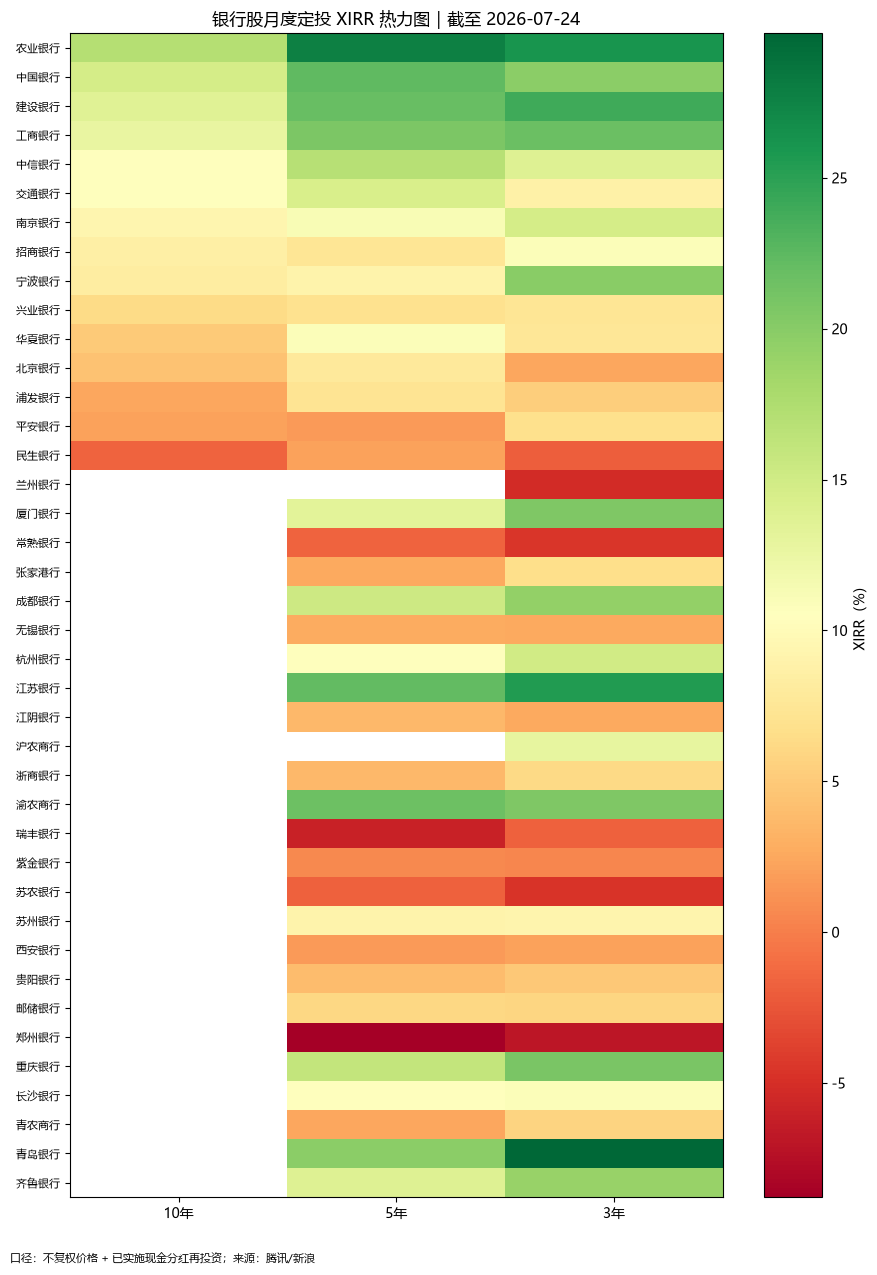

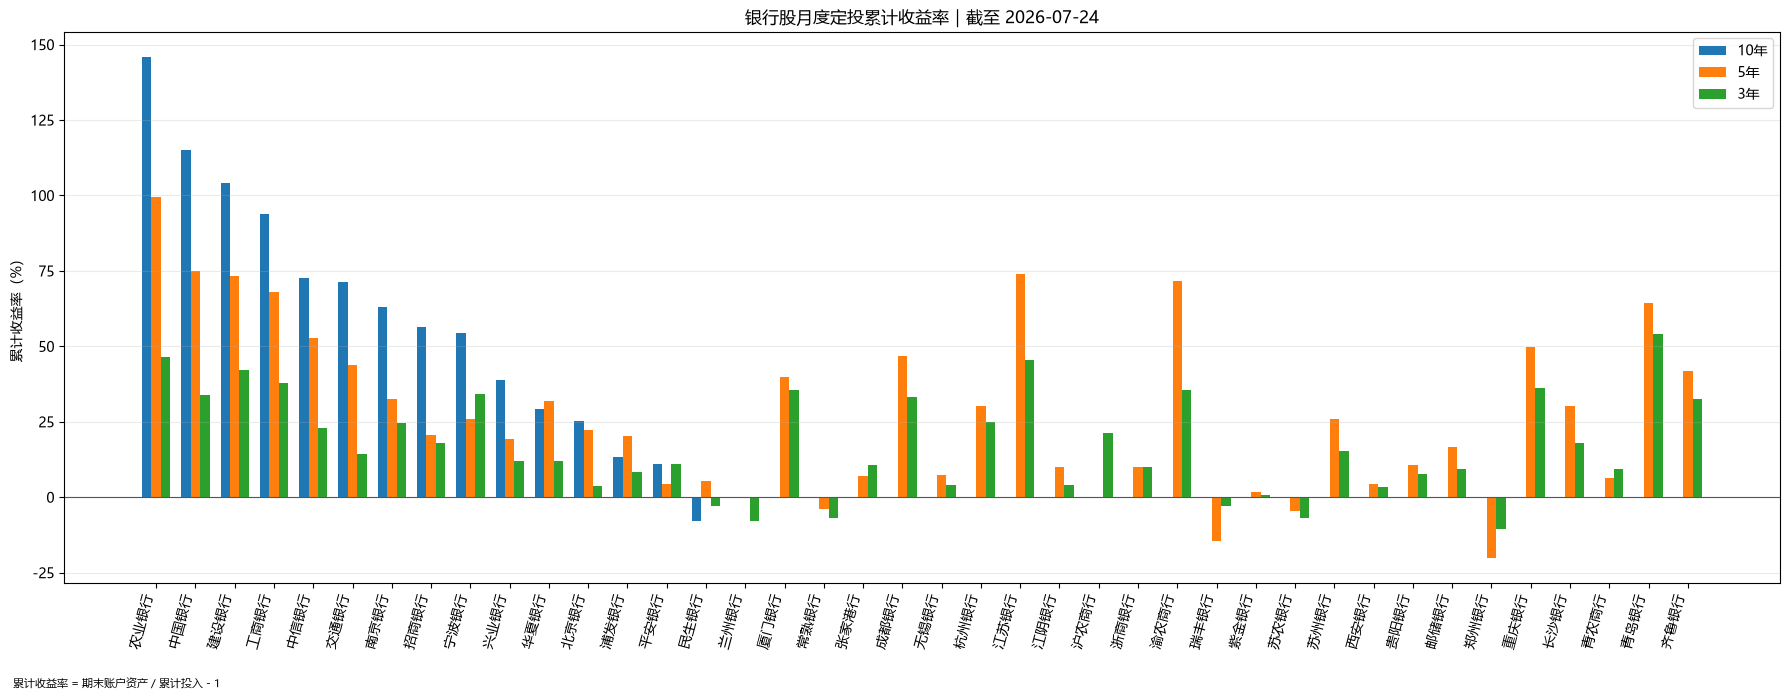

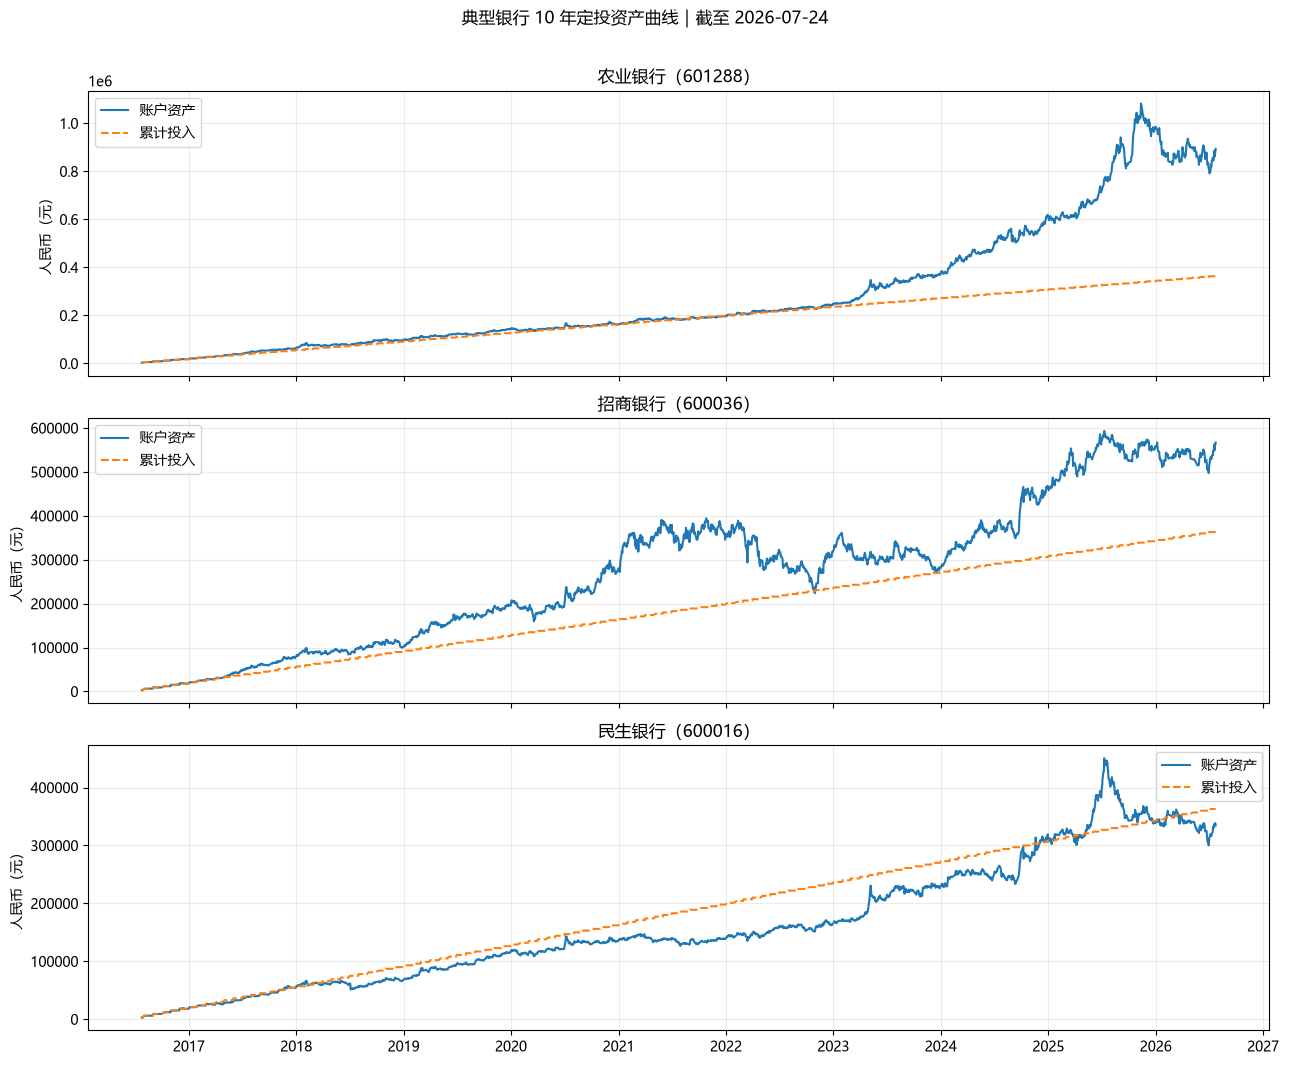

In [11]:
complete = results[results["full_horizon"].eq(True)].copy()
complete["horizon_years"] = complete["horizon"].str.rstrip("Y").astype(int)
horizon_order = [10, 5, 3]

# 图1：三周期 XIRR 热力图
xirr_pivot = (
    complete.pivot(index="name", columns="horizon_years", values="xirr")
    .reindex(columns=horizon_order)
)
if 10 in xirr_pivot:
    xirr_pivot = xirr_pivot.sort_values(10, ascending=False)
fig, ax = plt.subplots(figsize=(9, max(10, len(xirr_pivot) * 0.32)))
image = ax.imshow(xirr_pivot.to_numpy() * 100, aspect="auto", cmap="RdYlGn")
ax.set_yticks(range(len(xirr_pivot)), labels=xirr_pivot.index, fontsize=8)
ax.set_xticks(range(len(xirr_pivot.columns)), labels=[f"{x}年" for x in xirr_pivot.columns])
ax.set_title(f"银行股月度定投 XIRR 热力图｜截至 {AS_OF_DATE}")
fig.colorbar(image, ax=ax, label="XIRR（%）")
fig.text(0.01, 0.01, "口径：不复权价格 + 已实施现金分红再投资；来源：腾讯/新浪", fontsize=8)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(CHART_DIR / "01_xirr_heatmap.png", dpi=180)
plt.show()

# 图2：累计收益率分组柱状图
return_pivot = (
    complete.pivot(index="name", columns="horizon_years", values="total_return")
    .reindex(index=xirr_pivot.index, columns=horizon_order)
)
positions = np.arange(len(return_pivot))
width = 0.24
fig, ax = plt.subplots(figsize=(max(16, len(return_pivot) * 0.45), 7))
for offset, horizon in zip((-width, 0, width), horizon_order):
    ax.bar(
        positions + offset,
        return_pivot[horizon].to_numpy() * 100,
        width,
        label=f"{horizon}年",
    )
ax.axhline(0, color="#555", linewidth=0.8)
ax.set_xticks(positions, labels=return_pivot.index, rotation=75, ha="right")
ax.set_ylabel("累计收益率（%）")
ax.set_title(f"银行股月度定投累计收益率｜截至 {AS_OF_DATE}")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.text(0.01, 0.01, "累计收益率 = 期末账户资产 / 累计投入 - 1", fontsize=8)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(CHART_DIR / "02_total_return_grouped_bar.png", dpi=180)
plt.show()

# 图3：典型银行资产曲线（10年 XIRR 的高位/中位/低位样本）
ten_year = complete[complete["horizon_years"].eq(10)].sort_values("xirr")
if len(ten_year) >= 3:
    typical_symbols = [
        ten_year.iloc[-1]["symbol"],
        ten_year.iloc[len(ten_year) // 2]["symbol"],
        ten_year.iloc[0]["symbol"],
    ]
else:
    typical_symbols = ten_year["symbol"].tolist()
fig, axes = plt.subplots(
    len(typical_symbols), 1,
    figsize=(13, max(4, 3.5 * len(typical_symbols))),
    sharex=True,
)
axes = np.atleast_1d(axes)
for ax, symbol in zip(axes, typical_symbols):
    history = account_history[
        account_history["symbol"].eq(symbol)
        & account_history["horizon"].eq("10Y")
    ]
    if history.empty:
        continue
    ax.plot(history["date"], history["account_asset"], label="账户资产")
    ax.plot(
        history["date"], history["cumulative_contribution"],
        linestyle="--", label="累计投入",
    )
    ax.set_title(f"{history['name'].iloc[0]}（{symbol}）")
    ax.set_ylabel("人民币（元）")
    ax.legend()
    ax.grid(alpha=0.25)
fig.suptitle(f"典型银行 10 年定投资产曲线｜截至 {AS_OF_DATE}", y=1.01)
fig.tight_layout()
fig.savefig(CHART_DIR / "03_typical_bank_asset_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## 14. 绘制风险和分红贡献图


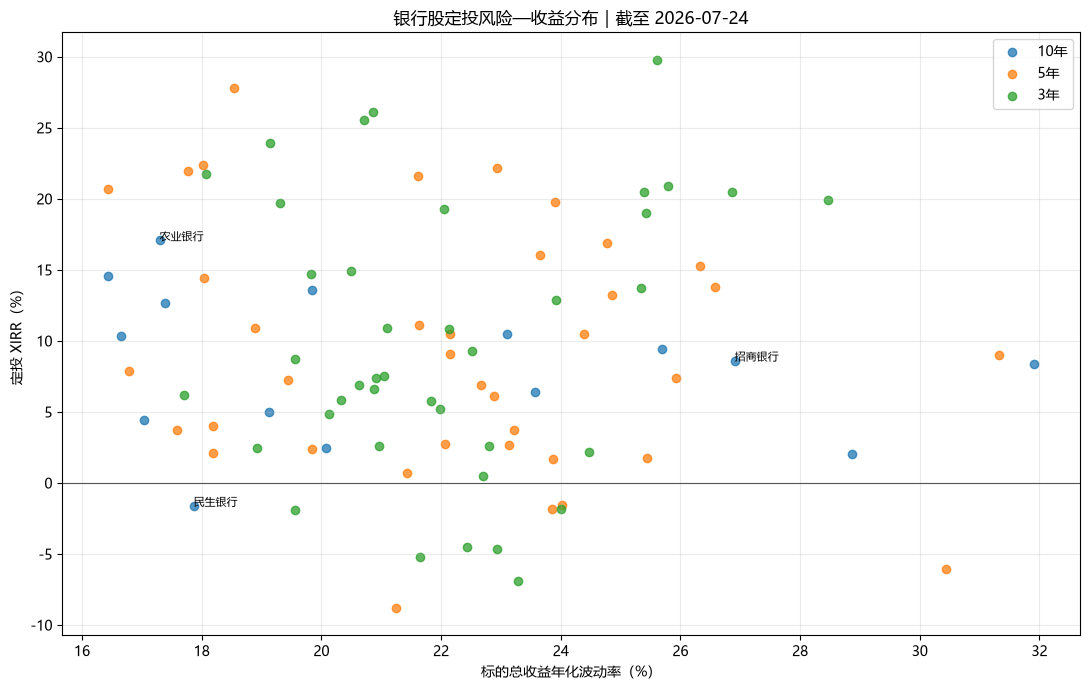

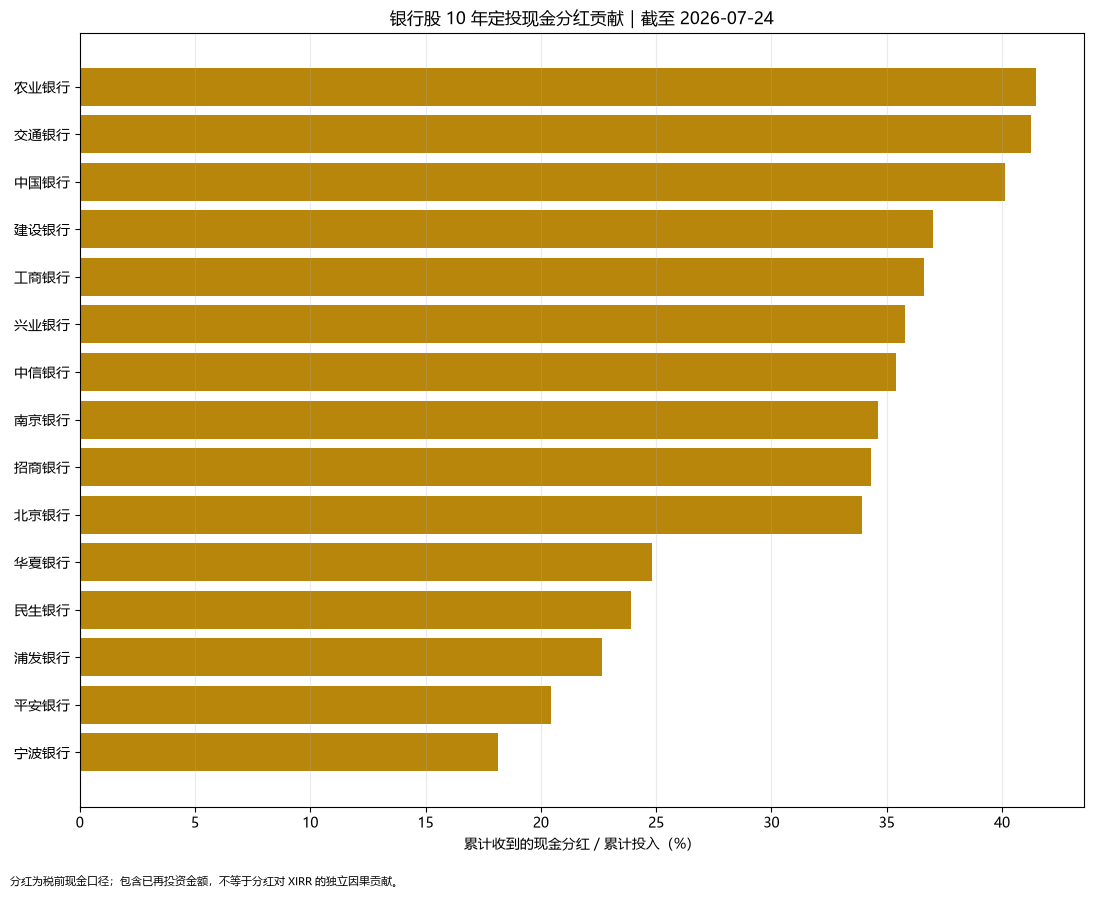

In [12]:
# 图4：风险收益散点图
fig, ax = plt.subplots(figsize=(11, 7))
colors = {10: "#1f77b4", 5: "#ff7f0e", 3: "#2ca02c"}
for horizon in horizon_order:
    subset = complete[complete["horizon_years"].eq(horizon)]
    ax.scatter(
        subset["volatility"] * 100,
        subset["xirr"] * 100,
        label=f"{horizon}年",
        alpha=0.75,
        color=colors[horizon],
    )
for row in ten_year.iloc[[0, len(ten_year)//2, -1]].itertuples(index=False) if len(ten_year) >= 3 else []:
    ax.annotate(row.name, (row.volatility * 100, row.xirr * 100), fontsize=8)
ax.axhline(0, color="#555", linewidth=0.8)
ax.set_xlabel("标的总收益年化波动率（%）")
ax.set_ylabel("定投 XIRR（%）")
ax.set_title(f"银行股定投风险—收益分布｜截至 {AS_OF_DATE}")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(CHART_DIR / "04_risk_return_scatter.png", dpi=180)
plt.show()

# 图5：分红贡献图
dividend_plot = complete[complete["horizon_years"].eq(10)].copy()
dividend_plot["dividend_vs_contribution"] = (
    dividend_plot["total_dividend"] / dividend_plot["total_contribution"]
)
dividend_plot = dividend_plot.sort_values("dividend_vs_contribution")
fig, ax = plt.subplots(figsize=(11, max(9, len(dividend_plot) * 0.3)))
ax.barh(
    dividend_plot["name"],
    dividend_plot["dividend_vs_contribution"] * 100,
    color="#b8860b",
)
ax.set_xlabel("累计收到的现金分红 / 累计投入（%）")
ax.set_title(f"银行股 10 年定投现金分红贡献｜截至 {AS_OF_DATE}")
ax.grid(axis="x", alpha=0.25)
fig.text(
    0.01, 0.01,
    "分红为税前现金口径；包含已再投资金额，不等于分红对 XIRR 的独立因果贡献。",
    fontsize=8,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(CHART_DIR / "05_dividend_contribution.png", dpi=180)
plt.show()


## 15. 保存实验结果和运行快照


In [13]:
manifest = {
    "generated_at": datetime.now().astimezone().isoformat(),
    "as_of_date": AS_OF_DATE,
    "market": "A-share banks",
    "currency": "CNY",
    "parameters": {
        "monthly_amount": MONTHLY_AMOUNT,
        "buy_day": BUY_DAY,
        "lot_size": LOT_SIZE,
        "dividend_reinvest": DIVIDEND_REINVEST,
        "fees": 0,
        "dividend_tax": 0,
        "horizons_years": list(HORIZONS),
        "price_relative_diff_tolerance": PRICE_REL_DIFF_TOLERANCE,
        "require_dual_source_qc": REQUIRE_DUAL_SOURCE_QC,
    },
    "routes": source_routes.to_dict("records"),
    "counts": {
        "bank_universe": len(bank_universe),
        "analysis_universe": len(analysis_universe),
        "quality_passed": int(quality_report["eligible_for_backtest"].sum()),
        "result_rows": len(results),
    },
    "outputs": {
        "bank_universe": "bank_universe.csv",
        "quality_report": "quality_report.csv",
        "backtest_results": "results/backtest_results.csv",
        "transactions": "results/transactions.parquet",
        "account_history": "results/account_history.parquet",
        "total_return_history": "results/total_return_history.parquet",
        "charts": "charts/",
    },
    "limitations": [
        "分红缺少实际到账日时，以除权除息日近似",
        "不计算手续费与分红税",
        "人工核验股票池截止 2026-07-24",
        "接口可用性会随网络、IP 和上游字段变化",
        "历史回测不构成收益承诺",
    ],
}
with (DATA_DIR / "run_manifest.json").open("w", encoding="utf-8") as file:
    json.dump(manifest, file, ensure_ascii=False, indent=2)
print(json.dumps(manifest, ensure_ascii=False, indent=2))


{
  "generated_at": "2026-07-25T14:58:22.450903+08:00",
  "as_of_date": "2026-07-24",
  "market": "A-share banks",
  "currency": "CNY",
  "parameters": {
    "monthly_amount": 3000,
    "buy_day": 1,
    "lot_size": 100,
    "dividend_reinvest": true,
    "fees": 0,
    "dividend_tax": 0,
    "horizons_years": [
      10,
      5,
      3
    ],
    "price_relative_diff_tolerance": 0.002,
    "require_dual_source_qc": true
  },
  "routes": [
    {
      "数据": "银行股票池",
      "接口": "交易所股票清单",
      "真实上游": "上交所+深交所+北交所",
      "路由决策": "PRIMARY"
    },
    {
      "数据": "行业验证",
      "接口": "mootdx F10",
      "真实上游": "通达信 TCP",
      "路由决策": "PRIMARY"
    },
    {
      "数据": "不复权行情",
      "接口": "stock_zh_a_hist_tx",
      "真实上游": "腾讯财经",
      "路由决策": "PRIMARY"
    },
    {
      "数据": "不复权行情",
      "接口": "stock_zh_a_daily",
      "真实上游": "新浪财经",
      "路由决策": "BACKUP+QC"
    },
    {
      "数据": "前复权行情",
      "接口": "stock_zh_a_hist_tx",
      "真实上游": "腾讯财经",
      "路由决策": "PRIMARY"
 

## 16. 实验结论与数据局限


In [14]:
complete_ten = results[
    results["horizon"].eq("10Y") & results["full_horizon"].eq(True)
].dropna(subset=["xirr"])
blocked_count = int((~quality_report["eligible_for_backtest"]).sum())
blocked_result_count = int(results["backtest_status"].eq("BLOCKED_DATA_QUALITY").sum())
incomplete_count = int(results["backtest_status"].eq("INCOMPLETE_WINDOW").sum())
error_count = int(results["backtest_status"].eq("ERROR").sum())

if not complete_ten.empty:
    highest = complete_ten.loc[complete_ten["xirr"].idxmax()]
    lowest = complete_ten.loc[complete_ten["xirr"].idxmin()]
    print(
        f"完整10年窗口 {len(complete_ten)} 只；"
        f"本次样本 XIRR 最高为 {highest['name']} {highest['xirr']:.2%}，"
        f"最低为 {lowest['name']} {lowest['xirr']:.2%}。"
    )
print(
    f"因数据质量停止回测 {blocked_count} 只（保留 {blocked_result_count} 行 N/A）；"
    f"不满足完整窗口的结果 {incomplete_count} 行；执行错误 {error_count} 行。"
)
print(
    "这些是给定口径下的历史实验结果，不代表未来收益。"
    "未计手续费、分红税，且分红到账日采用除权除息日近似。"
)


完整10年窗口 15 只；本次样本 XIRR 最高为 农业银行 17.08%，最低为 民生银行 -1.61%。
因数据质量停止回测 2 只（保留 6 行 N/A）；不满足完整窗口的结果 27 行；执行错误 0 行。
这些是给定口径下的历史实验结果，不代表未来收益。未计手续费、分红税，且分红到账日采用除权除息日近似。
